In [1]:
import sys
print(sys.executable)
print(sys.version)


C:\Users\ASUS\OneDrive\Desktop\pto\Credit-Risk-Modeling\myenvi\Scripts\python.exe
3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


In [2]:

!pip -V


pip 24.2 from C:\Users\ASUS\OneDrive\Desktop\pto\Credit-Risk-Modeling\myenvi\Lib\site-packages\pip (python 3.12)



In [3]:
!C:\Users\ASUS\OneDrive\Desktop\pto\Credit-Risk-Modeling\myenvi\Scripts\python.exe -m pip install ipykernel


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!C:\Users\ASUS\OneDrive\Desktop\pto\Credit-Risk-Modeling\myenvi\Scripts\python.exe -m ipykernel install --user --name myenvi --display-name "Python (myenvi)"

Installed kernelspec myenvi in C:\Users\ASUS\AppData\Roaming\jupyter\kernels\myenvi


In [5]:
import sys
print(sys.executable)  # should point to ...\myenvi\Scripts\python.exe


C:\Users\ASUS\OneDrive\Desktop\pto\Credit-Risk-Modeling\myenvi\Scripts\python.exe


In [21]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

In [8]:
df = pd.read_csv("./cleaned2.csv")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42066 entries, 0 to 42065
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 42066 non-null  int64  
 1   pct_tl_open_L6M            42066 non-null  float64
 2   pct_tl_closed_L6M          42066 non-null  float64
 3   Tot_TL_closed_L12M         42066 non-null  int64  
 4   pct_tl_open_L12M           42066 non-null  float64
 5   pct_tl_closed_L12M         42066 non-null  float64
 6   Tot_Missed_Pmnt            42066 non-null  int64  
 7   CC_TL                      42066 non-null  int64  
 8   Home_TL                    42066 non-null  int64  
 9   PL_TL                      42066 non-null  int64  
 10  Secured_TL                 42066 non-null  int64  
 11  Unsecured_TL               42066 non-null  int64  
 12  Other_TL                   42066 non-null  int64  
 13  time_since_recent_payment  42066 non-null  int

In [10]:
# Label Encoding for categorical features

["MARITALSTATUS","EDUCATION","GENDER","last_prod_enq2","first_prod_enq2"]

['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']

In [11]:
print("education",df["EDUCATION"].unique())
print("MARITALSTATUS",df["MARITALSTATUS"].unique())
print("GENDER",df["GENDER"].unique())
print("last_prod_enq2",df["last_prod_enq2"].unique())
print("first_prod_enq2",df["first_prod_enq2"].unique())

education ['12TH' 'GRADUATE' 'SSC' 'POST-GRADUATE' 'UNDER GRADUATE' 'OTHERS'
 'PROFESSIONAL']
MARITALSTATUS ['Married' 'Single']
GENDER ['M' 'F']
last_prod_enq2 ['PL' 'ConsumerLoan' 'AL' 'CC' 'others' 'HL']
first_prod_enq2 ['PL' 'ConsumerLoan' 'others' 'AL' 'HL' 'CC']


In [12]:
# cannot do one hot encoding to education field as it contains multiple feature
# Ordinal feature -- EDUCATION
# SSC            : 1
# 12TH           : 2
# GRADUATE       : 3
# UNDER GRADUATE : 3
# POST-GRADUATE  : 4
# OTHERS         : 1
# PROFESSIONAL   : 3

In [13]:
df.loc[df['EDUCATION'] == 'SSC',['EDUCATION']]              = 1
df.loc[df['EDUCATION'] == '12TH',['EDUCATION']]             = 2
df.loc[df['EDUCATION'] == 'GRADUATE',['EDUCATION']]         = 3
df.loc[df['EDUCATION'] == 'UNDER GRADUATE',['EDUCATION']]   = 3
df.loc[df['EDUCATION'] == 'POST-GRADUATE',['EDUCATION']]    = 4
df.loc[df['EDUCATION'] == 'OTHERS',['EDUCATION']]           = 1
df.loc[df['EDUCATION'] == 'PROFESSIONAL',['EDUCATION']]     = 3

In [14]:
df["EDUCATION"].value_counts()
df['EDUCATION'] = df['EDUCATION'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42066 entries, 0 to 42065
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 42066 non-null  int64  
 1   pct_tl_open_L6M            42066 non-null  float64
 2   pct_tl_closed_L6M          42066 non-null  float64
 3   Tot_TL_closed_L12M         42066 non-null  int64  
 4   pct_tl_open_L12M           42066 non-null  float64
 5   pct_tl_closed_L12M         42066 non-null  float64
 6   Tot_Missed_Pmnt            42066 non-null  int64  
 7   CC_TL                      42066 non-null  int64  
 8   Home_TL                    42066 non-null  int64  
 9   PL_TL                      42066 non-null  int64  
 10  Secured_TL                 42066 non-null  int64  
 11  Unsecured_TL               42066 non-null  int64  
 12  Other_TL                   42066 non-null  int64  
 13  time_since_recent_payment  42066 non-null  int

In [15]:
# one hote encoding
df_encoded = pd.get_dummies(df, columns=['MARITALSTATUS','GENDER', 'last_prod_enq2' ,'first_prod_enq2'])

In [16]:
df_encoded.info()
k = df_encoded.describe()
k

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42066 entries, 0 to 42065
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    42066 non-null  int64  
 1   pct_tl_open_L6M               42066 non-null  float64
 2   pct_tl_closed_L6M             42066 non-null  float64
 3   Tot_TL_closed_L12M            42066 non-null  int64  
 4   pct_tl_open_L12M              42066 non-null  float64
 5   pct_tl_closed_L12M            42066 non-null  float64
 6   Tot_Missed_Pmnt               42066 non-null  int64  
 7   CC_TL                         42066 non-null  int64  
 8   Home_TL                       42066 non-null  int64  
 9   PL_TL                         42066 non-null  int64  
 10  Secured_TL                    42066 non-null  int64  
 11  Unsecured_TL                  42066 non-null  int64  
 12  Other_TL                      42066 non-null  int64  
 13  t

,Unnamed: 0,pct_tl_open_L6M,pct_tl_closed_L6M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,CC_TL,Home_TL,PL_TL,...,enq_L3m,NETMONTHLYINCOME,Time_With_Curr_Empr,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,EDUCATION
count,42066.000000,42066.000000,42066.000000,42066.000000,42066.000000,42066.000000,42066.000000,42066.000000,42066.000000,42066.000000,...,42066.000000,4.206600e+04,42066.000000,42066.000000,42066.000000,42066.000000,42066.000000,42066.000000,42066.000000,42066.000000
mean,21032.500000,0.179024,0.097779,0.825465,0.401252,0.160357,0.525721,0.145914,0.076237,0.327985,...,1.230424,2.692937e+04,110.347763,0.102957,0.193054,0.195511,0.064183,0.252223,0.056578,2.313721
std,12143.552549,0.278039,0.210953,1.537182,0.381267,0.258827,1.106422,0.549302,0.358574,0.916349,...,2.069421,2.084265e+04,75.633548,0.303907,0.394700,0.367427,0.225984,0.434294,0.231037,0.871063
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,10516.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.800000e+04,61.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,21032.500000,0.000000,0.000000,0.000000,0.333000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.400000e+04,92.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,31548.750000,0.333000,0.100000,1.000000,0.714000,0.250000,1.000000,0.000000,0.000000,0.000000,...,2.000000,3.100000e+04,131.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000
max,42065.000000,1.000000,1.000000,33.000000,1.000000,1.000000,34.000000,27.000000,10.000000,29.000000,...,42.000000,2.500000e+06,1020.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000


In [17]:
df_encoded

,Unnamed: 0,pct_tl_open_L6M,pct_tl_closed_L6M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,CC_TL,Home_TL,PL_TL,...,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,first_prod_enq2_AL,first_prod_enq2_CC,first_prod_enq2_ConsumerLoan,first_prod_enq2_HL,first_prod_enq2_PL,first_prod_enq2_others
0,0,0.000,0.00,0,0.000,0.000,0,0,0,4,...,False,False,True,False,False,False,False,False,True,False
1,1,0.000,0.00,0,1.000,0.000,0,0,0,0,...,True,False,False,False,False,False,True,False,False,False
2,2,0.125,0.00,0,0.250,0.000,1,0,0,0,...,True,False,False,False,False,False,False,False,False,True
3,3,0.000,0.00,0,0.000,0.000,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
4,4,0.000,0.00,1,0.000,0.167,0,0,0,0,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42061,42061,0.333,0.00,0,0.333,0.000,0,0,0,0,...,True,False,False,False,False,False,True,False,False,False
42062,42062,0.000,0.25,1,0.500,0.250,0,0,0,0,...,False,False,False,True,False,False,False,False,False,True
42063,42063,0.500,0.50,1,1.000,0.500,0,0,0,0,...,True,False,False,False,False,False,False,False,False,True
42064,42064,0.000,0.00,1,0.500,0.500,0,0,0,0,...,True,False,False,False,False,False,False,False,False,True


In [18]:
# machine learning model fitting


Accuracy: 0.7393629664844307

Class p1:
Precision: 0.7741935483870968
Recall: 0.46961894953656025
F1 Score: 0.5846153846153846

Class p2:
Precision: 0.7607420326621215
Recall: 0.9334630350194553
F1 Score: 0.8382982440814187

Class p3:
Precision: 0.4448979591836735
Recall: 0.17680454176804541
F1 Score: 0.253047011027278

Class p4:
Precision: 0.7285992217898832
Recall: 0.7
F1 Score: 0.7140133460438512



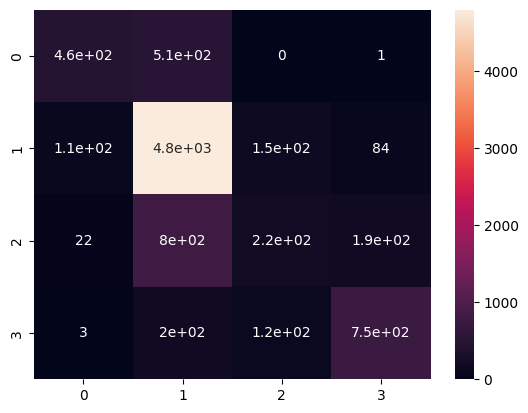

In [19]:
#1. Random forest
y = df_encoded["Approved_Flag"]
x =df_encoded.drop(["Approved_Flag"],axis = 1)

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=200,random_state=42)
rf_classifier.fit(X_train,y_train)

y_pred = rf_classifier.predict(X_test)

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

accuracy = accuracy_score(y_test, y_pred)
print ()
print(f'Accuracy: {accuracy}')
print ()
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred)

for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()


Accuracy: 0.75

Class p1:
Precision: 0.7489481065918654
Recall: 0.5499485066941298
F1 Score: 0.6342042755344418

Class p2:
Precision: 0.7844682992284469
Recall: 0.9099221789883268
F1 Score: 0.8425508917312196

Class p3:
Precision: 0.4369747899159664
Recall: 0.25304136253041365
F1 Score: 0.3204930662557781

Class p4:
Precision: 0.728780487804878
Recall: 0.6981308411214954
F1 Score: 0.713126491646778



In [22]:

# 3. Decision Tree



y = df_encoded['Approved_Flag']
x = df_encoded. drop ( ['Approved_Flag'], axis = 1 )

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


dt_model = DecisionTreeClassifier(max_depth=20, min_samples_split=10)
dt_model.fit(x_train, y_train)
y_pred = dt_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print ()
print(f"Accuracy: {accuracy:.2f}")
print ()

precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred)

for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()



Accuracy: 0.66

Class p1:
Precision: 0.5279831045406547
Recall: 0.5149330587023687
F1 Score: 0.5213764337851929

Class p2:
Precision: 0.7633531157270029
Recall: 0.8007782101167316
F1 Score: 0.7816179263197873

Class p3:
Precision: 0.31646734130634774
Recall: 0.27899432278994324
F1 Score: 0.296551724137931

Class p4:
Precision: 0.6336032388663968
Recall: 0.5850467289719626
F1 Score: 0.608357628765792

